# FitzHugh-Nagumo Simulations

This notebook shows solution behavior for a potential example with the FitzHugh-Nagumo equations.

Problem statement:

$$
\begin{align*}
    \frac{\partial q_1}{\partial t}
    &= \varepsilon \frac{\partial^2 q_{1}}{\partial x^2} + \frac{1}{\varepsilon}\left(-q_1^3 + 1.1 q_{1}^2 - 0.1 q_{1} - q_{2} + \alpha\right)
    \\
    \frac{\partial q_2}{\partial t}
    &= \beta q_{1} - \gamma q_{2} + \alpha
    \\
    \frac{\partial q_1}{\partial x}\big|_{x=0} &= f(t),
    \qquad
    \frac{\partial q_1}{\partial x}\big|_{x=1} = 0
\end{align*}
$$

The classes in `fhn.py` solve this problem.
The constructors take in the spatial domain and the system parameters $(\alpha,\beta,\gamma,\epsilon)$.
The left Neumann boundary condition function is parameterized with two positive constants $(a,b)$ as

$$
\begin{align*}
    f(t) = - a t^3 e^{- b t}.
\end{align*}
$$

Using a joint basis for $q_1$ and $q_2$, a reduced-order model of this system should have the following structure.

$$
\begin{align*}
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}
    &= \mathbf{c} + \mathbf{A}\mathbf{q} + \mathbf{H}[\mathbf{q}\otimes\mathbf{q}] + \mathbf{G}[\mathbf{q} \otimes \mathbf{q} \otimes \mathbf{q}] + \mathbf{B}\mathbf{u}.
\end{align*}
$$

Using individual bases for $q_1$ and $q_2$ of sizes $r_1$ and $r_2$, respectively, a Galerkin reduced-order model of this system has the following structure.

$$
\begin{align*}
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}_1
    &= \mathbf{c}_{1} + \mathbf{A}_{1,1}\mathbf{q}_{1} + \mathbf{A}_{1,2}\mathbf{q}_{2} + \mathbf{H}_{1,11}[\mathbf{q}_{1}\otimes\mathbf{q}_{1}] + \mathbf{G}_{1,111}[\mathbf{q}_1 \otimes \mathbf{q}_1 \otimes \mathbf{q}_1] + \mathbf{B}_{1}\mathbf{u},
    \\
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}_2
    &= \mathbf{c}_{2} + \mathbf{A}_{2,1}\mathbf{q}_{1} + \mathbf{A}_{2,2}\mathbf{q}_{2}.
\end{align*}
$$

In [6]:
import itertools
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

import config_fhnlifted
import pde_models_fn as pdes

## FitzHughNagumo

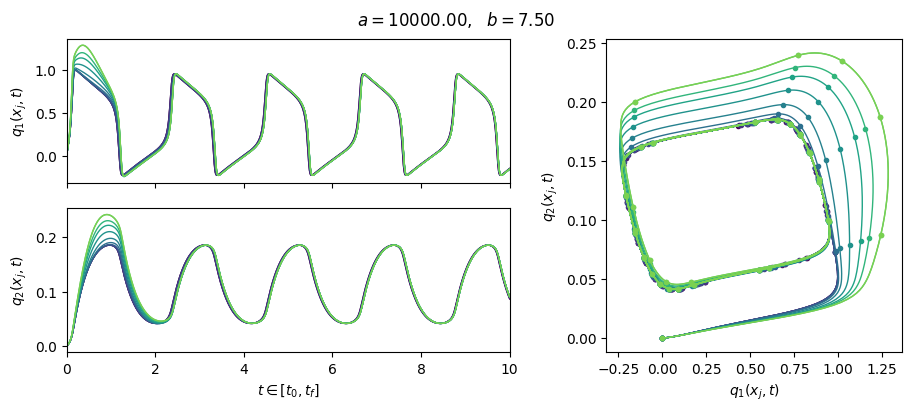

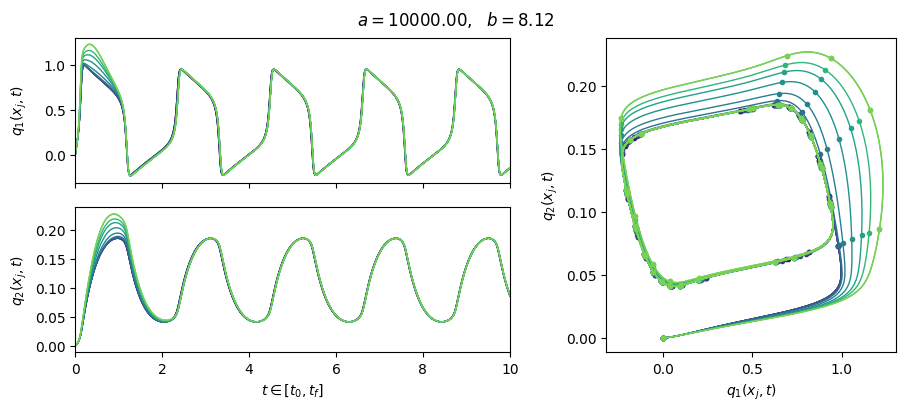

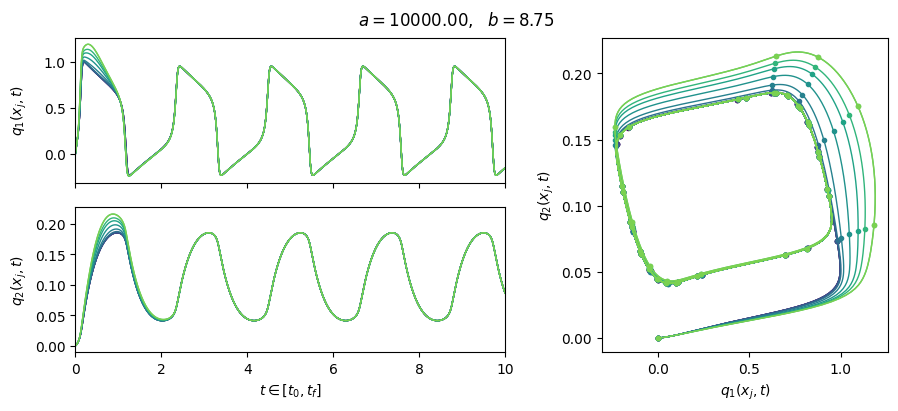

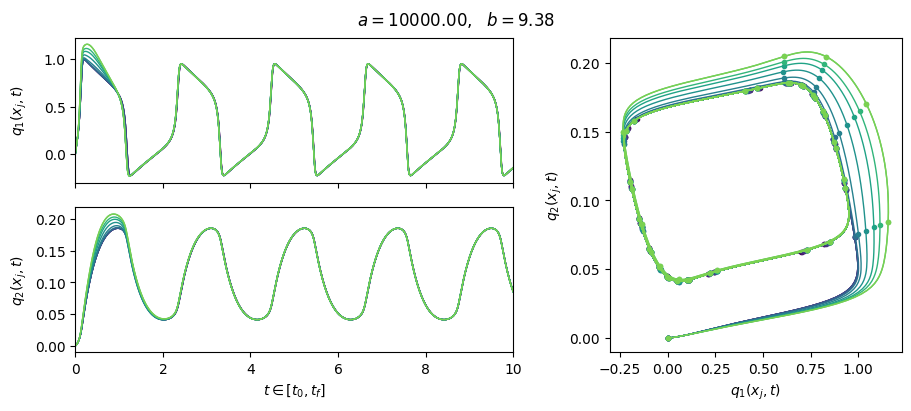

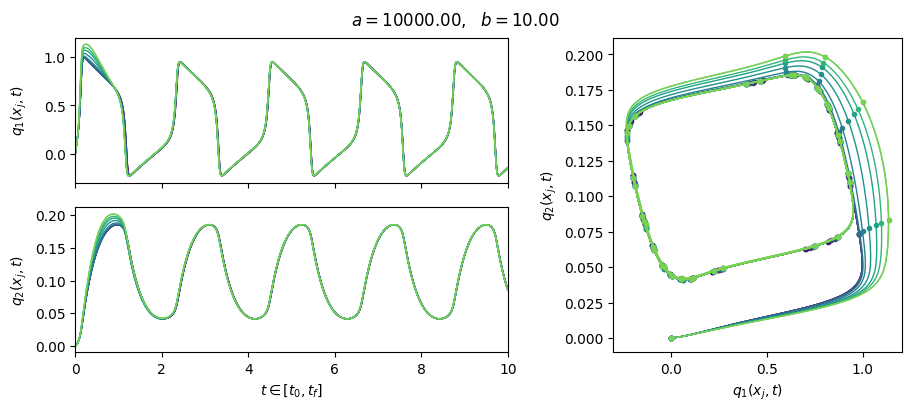

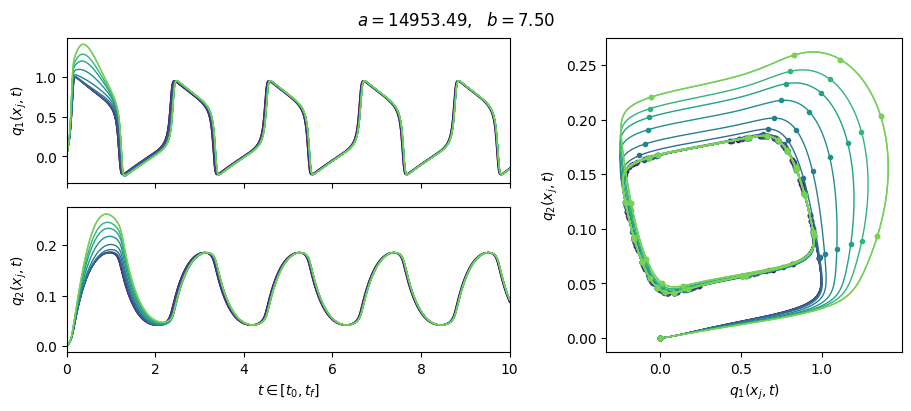

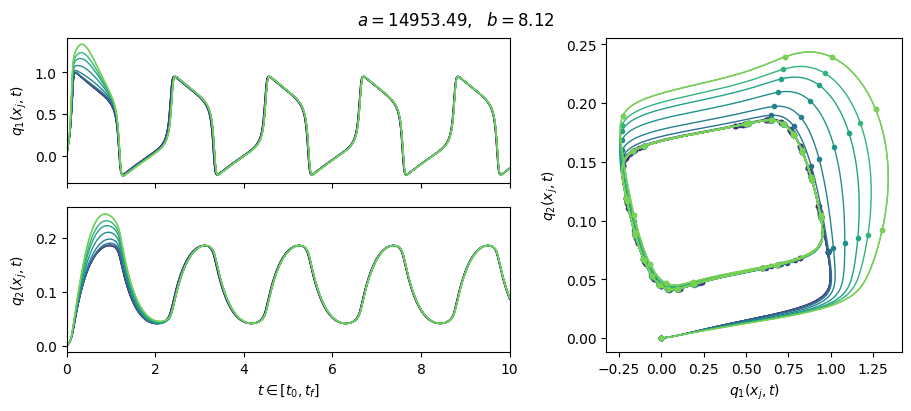

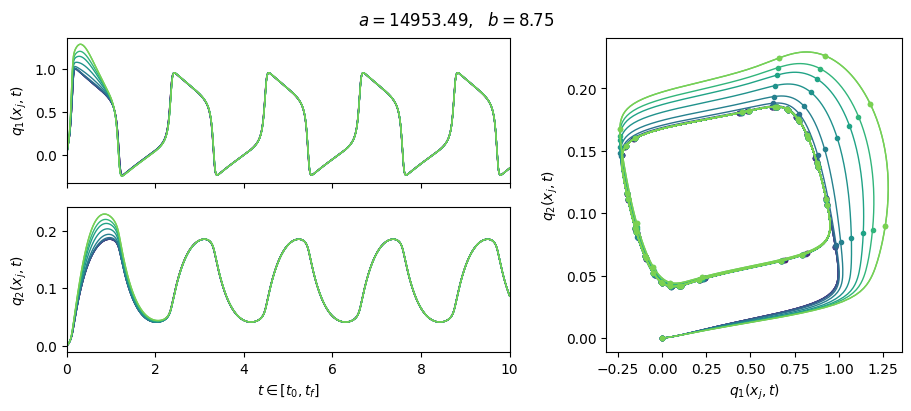

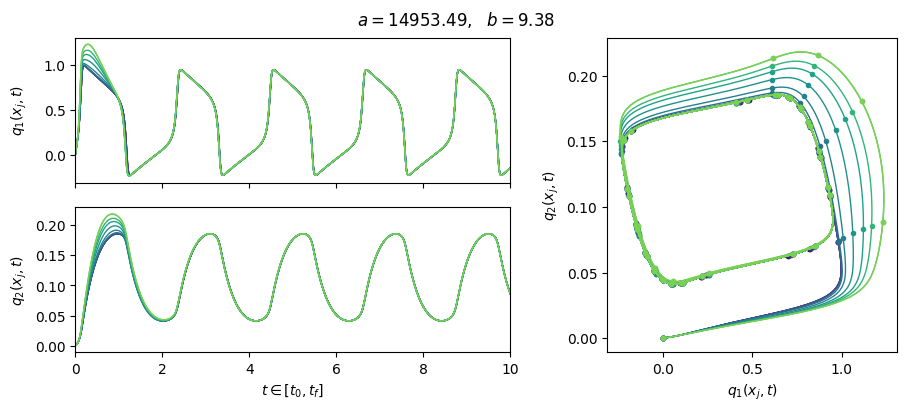

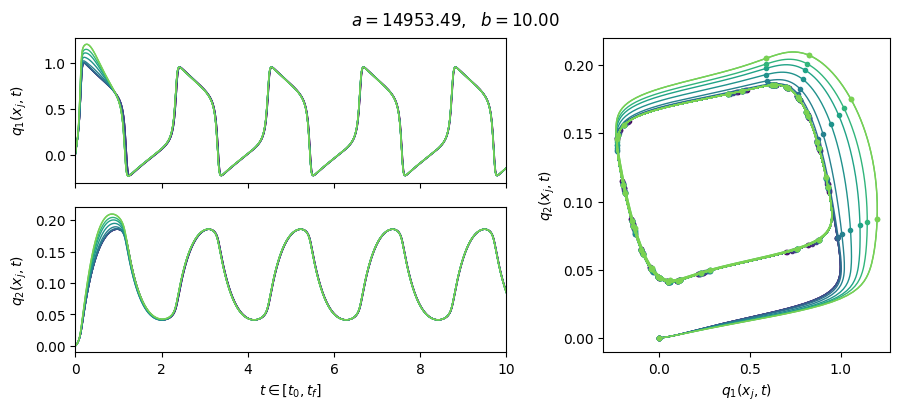

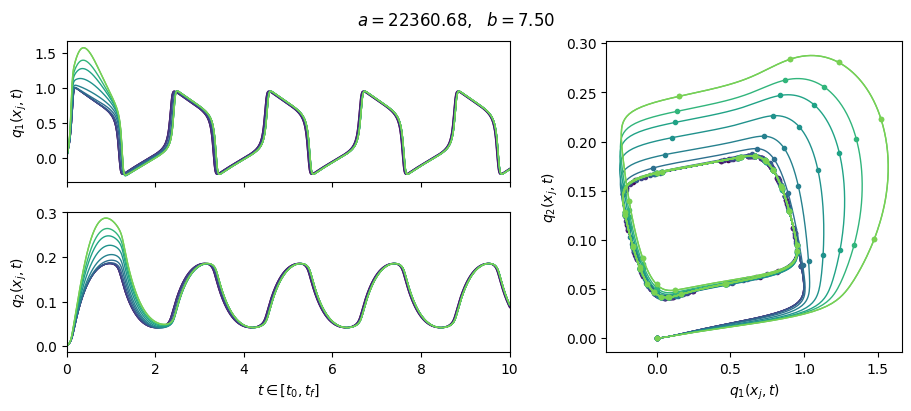

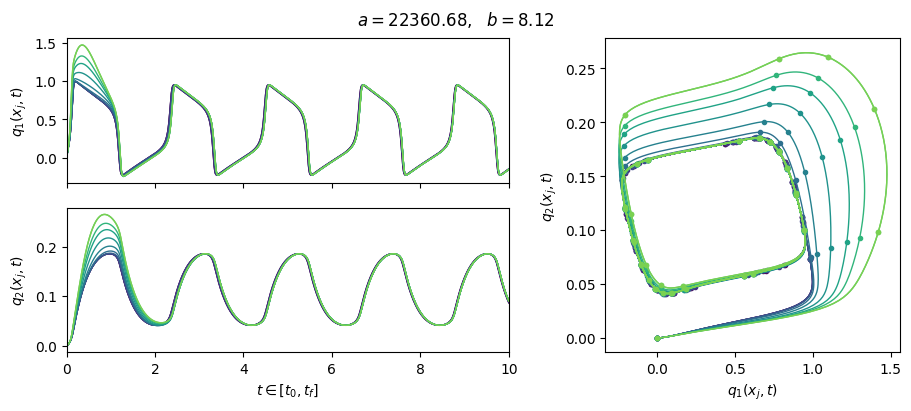

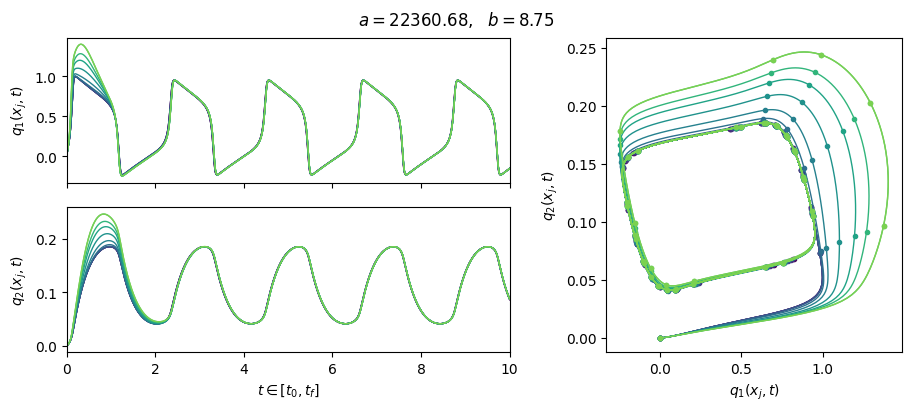

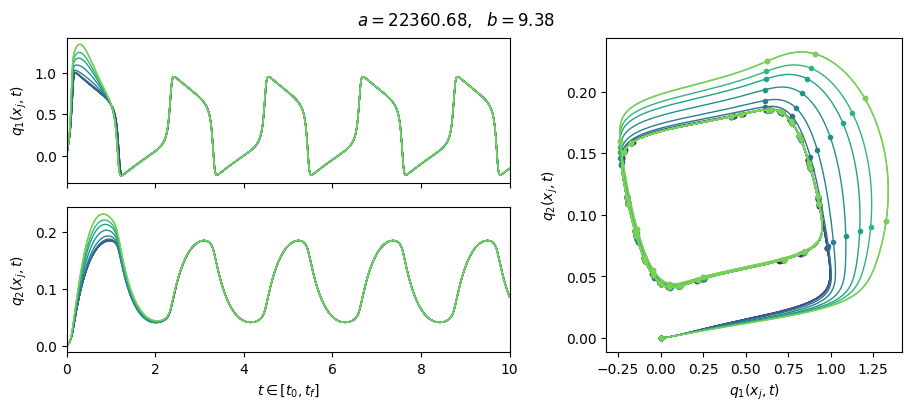

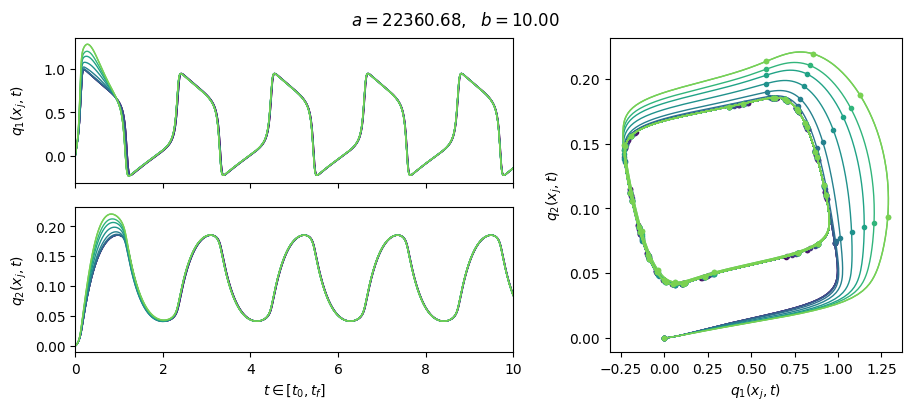

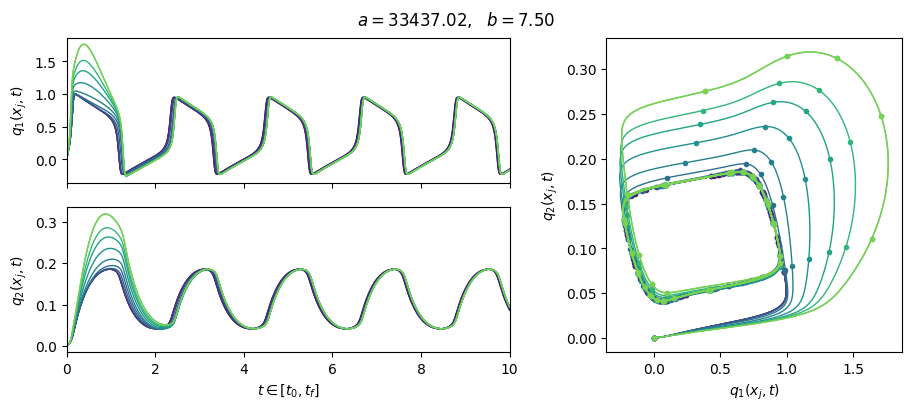

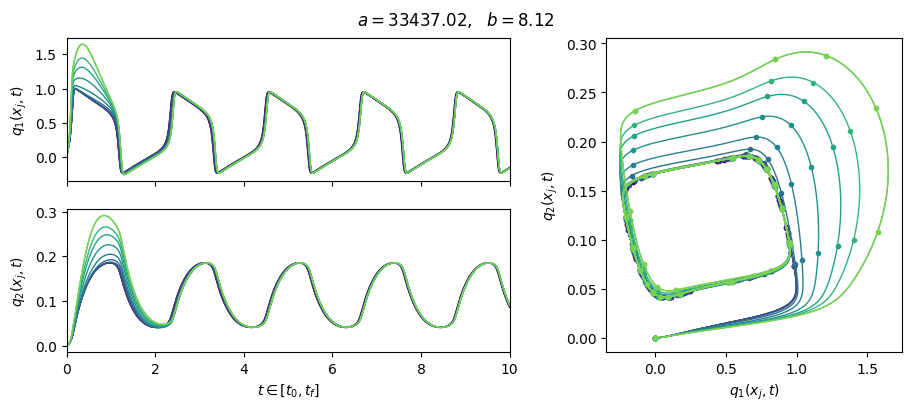

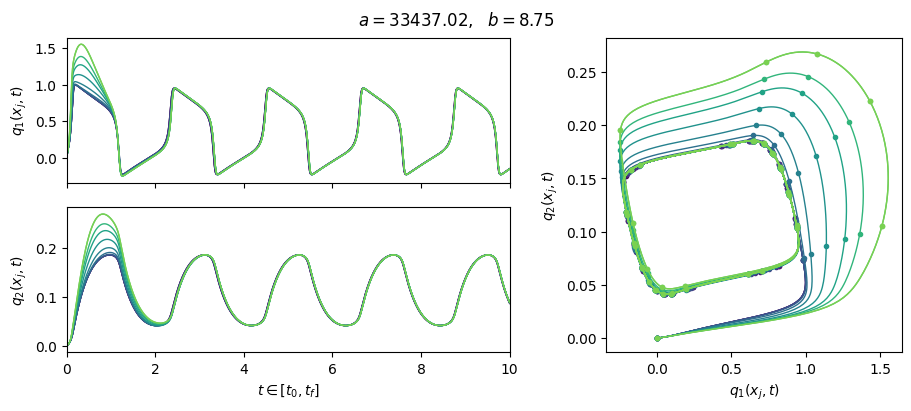

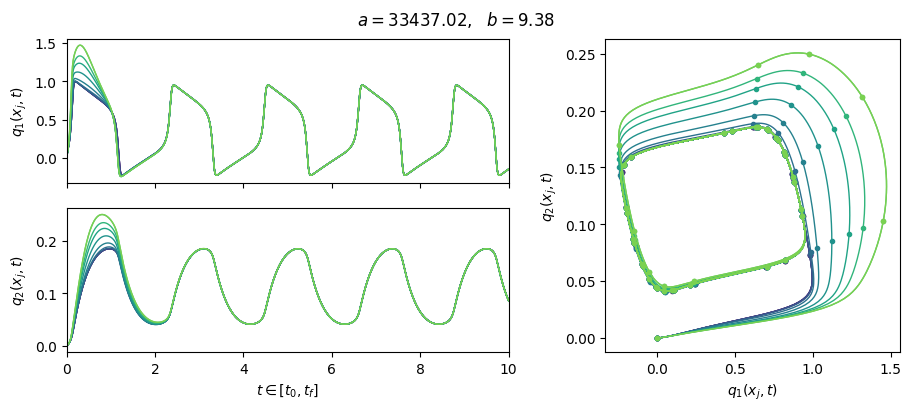

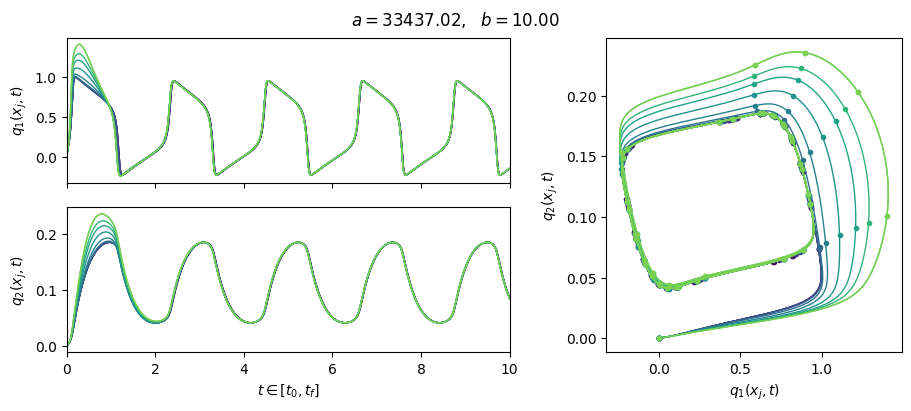

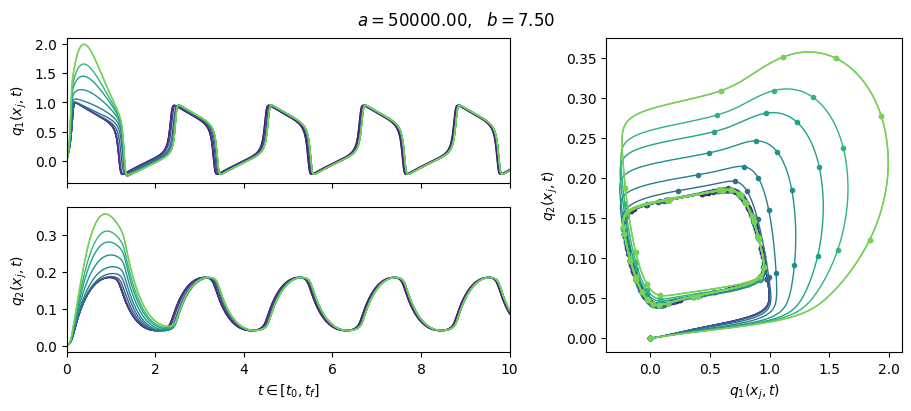

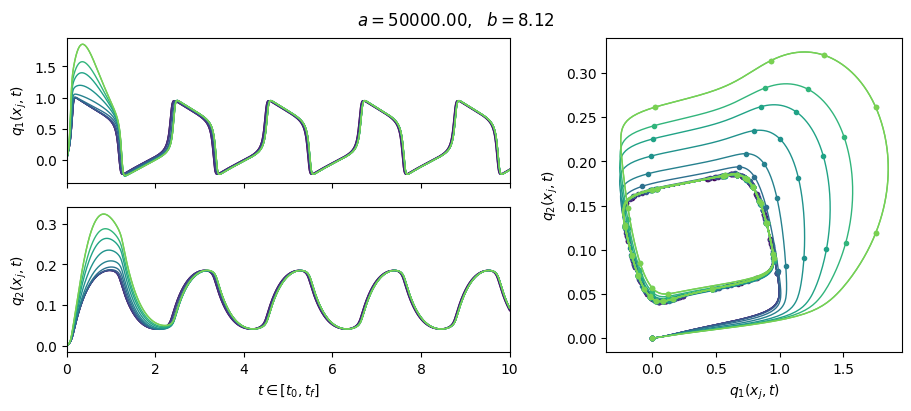

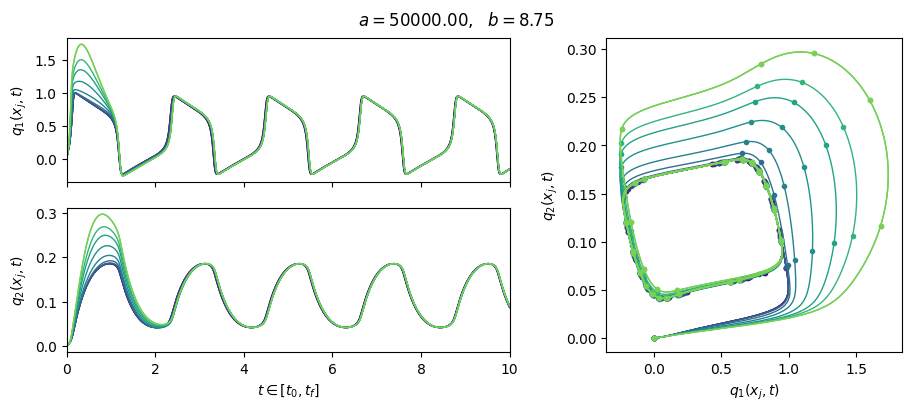

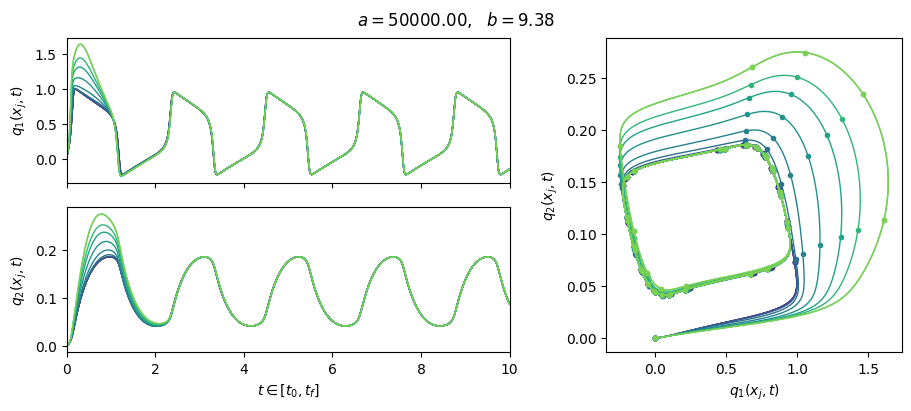

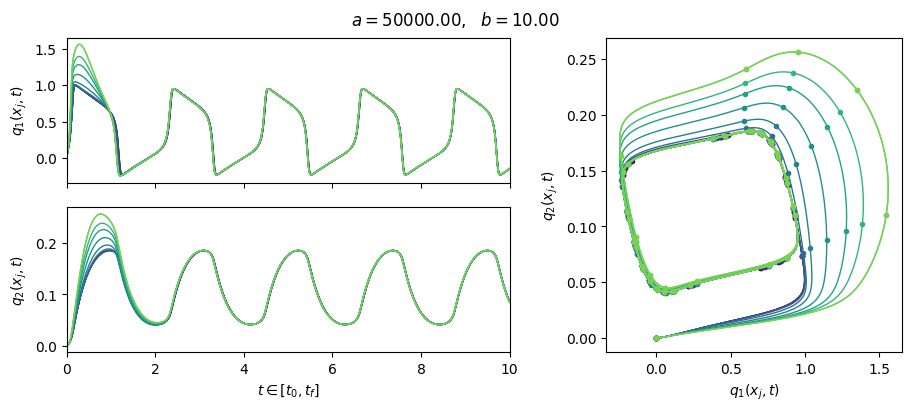

In [7]:
x = np.linspace(0, 1, 512)
t = np.linspace(0, int(4*2.5), int(801*2.5))

input_parameters = list(
    itertools.product(
        np.logspace(
            np.log10(10000), np.log10(50000), 5
        ),  # first NBC parameter
        np.linspace(7.5, 10, 5),  # b = second NBC parameter
    )
)

for a, b in input_parameters:
    fhnsolver = pdes.FitzHughNagumo(x, a=a, b=b)
    solution = fhnsolver.solve(None, t)

    fig, axes = fhnsolver.plot(solution, t, nlines=12)
    fig.suptitle(rf"$a = {a:.2f},~~b = {b:.2f}$")
    plt.show()

## Dimension Reduction and Noise

Is this reducible? Here's the singular value decay without noise.

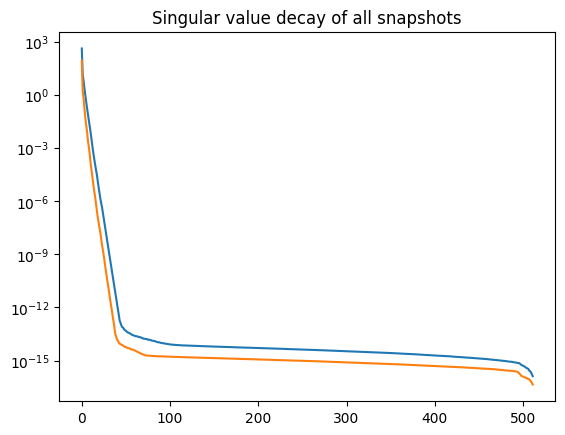

In [8]:
nx = solution.shape[0] // 2
plt.semilogy(la.svdvals(solution[:nx, : t.size // 2]))
plt.semilogy(la.svdvals(solution[nx:, : t.size // 2]))
plt.title("Singular value decay of all snapshots")
plt.show()

Cut off training at $t = 2$, predict for another $2$ time units.

(0.0, 100.0)

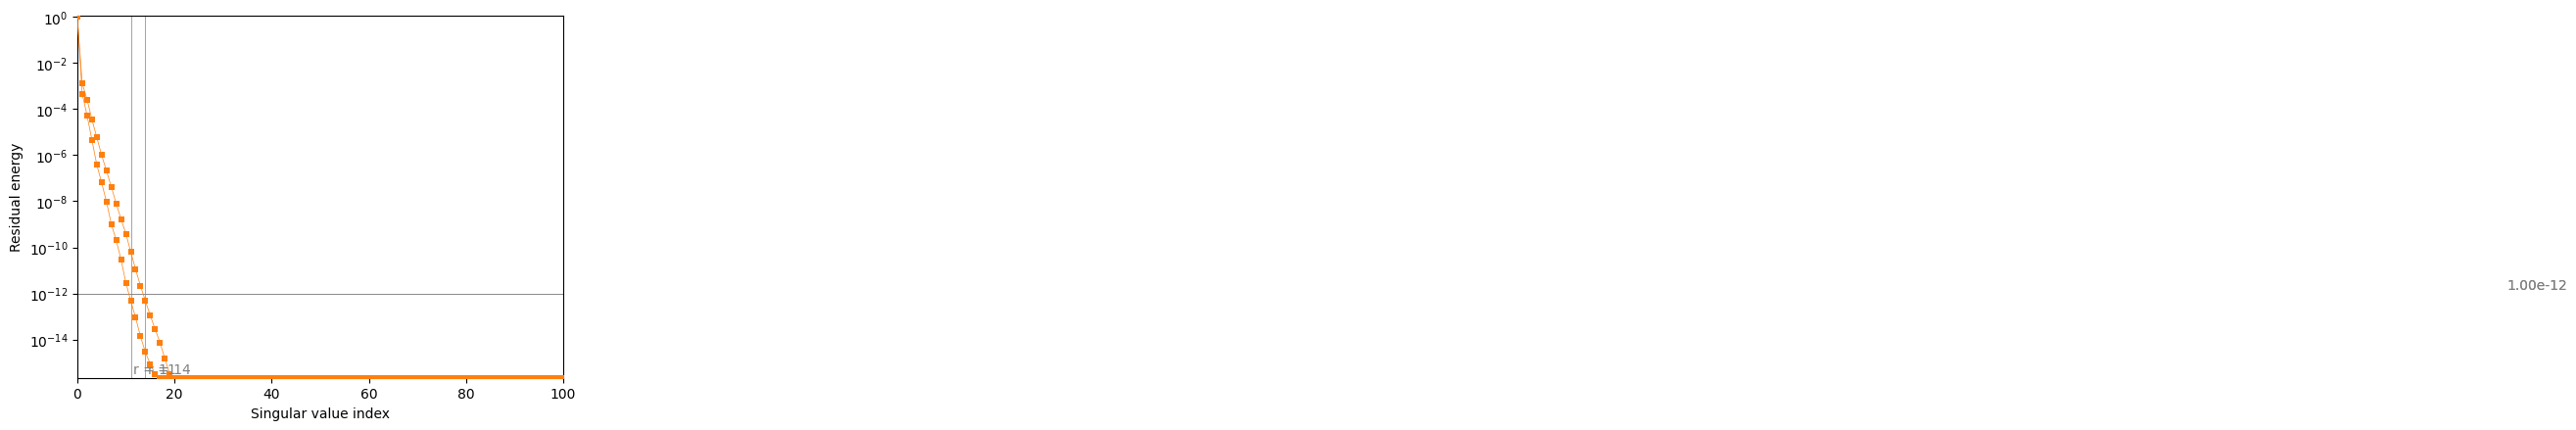

In [9]:
import opinf

fig, ax = plt.subplots(1, 1)
opinf.basis.residual_energy(
    la.svdvals(solution[:nx, : t.size // 2]), 1e-12, ax=ax
)
opinf.basis.residual_energy(
    la.svdvals(solution[nx:, : t.size // 2]), 1e-12, ax=ax
)
ax.set_xlim(right=100)

How is the singular value decay affected by noise?

<>:25: SyntaxWarning: invalid escape sequence '\%'
<>:25: SyntaxWarning: invalid escape sequence '\%'
/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_9166/1204771286.py:25: SyntaxWarning: invalid escape sequence '\%'
  label=f"S = {int(sparsity*100):d}\%, N = {noiselevel:.2e}",


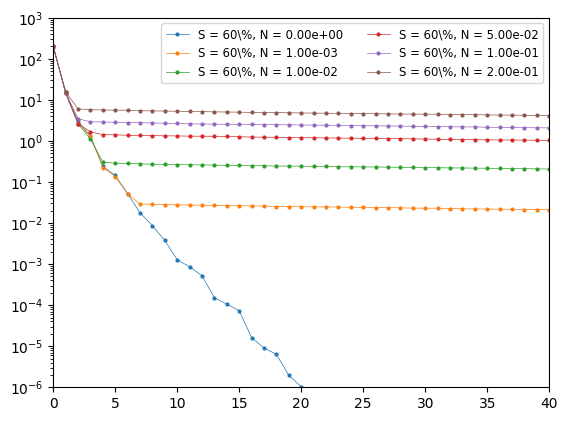

In [10]:
trainsize = 200
sparsity = 0.60

fig, ax = plt.subplots(1, 1)

for noiselevel in (0, 0.001, 0.01, 0.05, 0.10, 0.20):
    if sparsity >= 1:
        snapshots = solution
    else:
        sample_mask = np.sort(
            np.random.choice(
                trainsize,
                size=int(sparsity * trainsize),
                replace=False,
            )
        )
        snapshots = solution[:, sample_mask]
    # snapshots = fhnsolver.noise(snapshots, noiselevel, rseed=0)
    snapshots = fhnsolver.noise(snapshots, noiselevel)
    ax.semilogy(
        la.svdvals(snapshots),
        ".-",
        ms=4,
        lw=0.5,
        label=f"S = {int(sparsity*100):d}\%, N = {noiselevel:.2e}",
    )

ax.set_xlim(0, 40)
ax.set_ylim(1e-6, 1e3)
ax.legend(loc="upper right", ncol=2, fontsize="small")
plt.show()

## FitzHughNagumoLiftedSep

By introducing a new variable $q_{3} = q_{1}^{2}$, we can pose this problem as a quadratic (not a cubic) system.
Using the relation

$$
\begin{align*}
    \frac{\partial}{\partial t}q_{3}
    = 2 q_1 \frac{\partial}{\partial t}q_1,
\end{align*}
$$

the original equations can be written as

$$
\begin{align*}
    \frac{\partial q_1}{\partial t}
    &= \varepsilon \frac{\partial^2 q_{1}}{\partial x^2} + \frac{1}{\varepsilon}\left(-q_1 q_3 + 1.1 q_{3} - 0.1 q_{1} - q_{2} + \alpha\right)
    \\
    \frac{\partial q_2}{\partial t}
    &= \beta q_{1} - \gamma q_{2} + \alpha
    \\
    \frac{\partial q_3}{\partial t}
    &= 2\varepsilon q_1 \frac{\partial^2 q_{1}}{\partial x^2} + \frac{2}{\varepsilon}\left(-q_3^{2} + 1.1 q_{1}q_{3} - 0.1 q_{1}^{2} - q_{1}q_{2} + \alpha q_{1}\right)
    \\
    \frac{\partial q_1}{\partial x}\big|_{x=0} &= f(t),
    \qquad
    \frac{\partial q_1}{\partial x}\big|_{x=1} = 0
    \\
    \frac{\partial q_3}{\partial x}\big|_{x=0} &= q_{1}(0, t)f(t),
    \qquad
    \frac{\partial q_3}{\partial x}\big|_{x=1} = 0.
\end{align*}
$$

With a joint basis for $(q_1, q_2, q_3=q_1^2)$, we have the reduced-order model structure

$$
\begin{align*}
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}
    &= \mathbf{c} + \mathbf{A}\mathbf{q} + \mathbf{H}[\mathbf{q}\otimes\mathbf{q}] + \mathbf{B}\mathbf{u} + \mathbf{N}[\mathbf{u} \otimes \mathbf{q}].
\end{align*}
$$

By including the lifted variable, we have essentially traded the cubic term for a bilinear state-input interaction.

The form of a Galerkin reduced-order model with separate bases is

$$
\begin{align*}
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}_1
    &= \mathbf{c}_{1} + \mathbf{A}_{1,1}\mathbf{q}_{1} + \mathbf{A}_{1,2}\mathbf{q}_{2} + \mathbf{A}_{1,3}\mathbf{q}_{3} + \mathbf{H}_{1,13}[\mathbf{q}_1 \otimes \mathbf{q}_3] + \mathbf{B}_{1}\mathbf{u}
    \\
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}_2
    &= \mathbf{c}_{2} + \mathbf{A}_{2,1}\mathbf{q}_{1} + \mathbf{A}_{2,2}\mathbf{q}_{2}
    \\
    \frac{\textrm{d}}{\textrm{dt}}\mathbf{q}_3
    &= \mathbf{A}_{3,1}\mathbf{q}_{1} + \mathbf{H}_{3,11}[\mathbf{q}_{1}\otimes\mathbf{q}_{1}] + \mathbf{H}_{3,12}[\mathbf{q}_{1}\otimes\mathbf{q}_{2}] + \mathbf{H}_{3,13}[\mathbf{q}_{1}\otimes\mathbf{q}_{3}] + \mathbf{H}_{3,33}[\mathbf{q}_{3}\otimes\mathbf{q}_{3}] + \mathbf{N}_{3,1}[\mathbf{u}\otimes\mathbf{q}_{1}]
\end{align*}
$$

Total number of entries to be learned (without compressing the quadratic/cubic interactions): 
$$
    r_1 (1 + r_1 + r_2 + r_3 + r_1 r_3 + m)
    + r_2 (1 + r_1 + r_2)
    + r_3 (r_1 + r_1^2 + r_1 r_2 + r_1 r_3 + r_3^2 + r_1 m).
$$

Looks ugly, but not as bad as $r_1^4$ for large enough $r_1$.